# Fase 5 — Evaluación e interpretabilidad
### NASA C-MAPSS FD001 — SHAP sobre el modelo de Fase 4

**Punto de partida.** No se reconstruye ningún pipeline de datos: se
cargan directamente `train/test_FD001_features_112.parquet` (Fase 2) y
el modelo ganador de Fase 4 (auto-detectado, ver sección 1 — no
necesariamente XGBoost, ver nota siguiente) + `models/final_scaler.pkl`.
La
Fase 5 original reconstruía desde cero —dentro del propio script de
evaluación— la carga cruda, el `GlobalMinMaxScaler` y las features
rolling: una **segunda** implementación completa del mismo pipeline
(la primera había sido la Fase 2 original). Esta versión no reimplementa
nada de eso.

**Corrección (sept. 2026): el modelo interpretado ya no está fijado a
"xgboost".** Una versión previa de este notebook (y de
`fase5_evaluacion.py`) cargaba `xgboost_fd001.pkl` con el nombre
escrito a mano — un default heredado de una revisión en la que
XGBoost sí era el mejor modelo en test. Esta auditoría encontró que,
en este entorno, **RandomForest supera a XGBoost** en test RMSE
(11.04 vs. 11.32 — ver `fase4_modelado.ipynb`, sección 4), y Fase 5
seguía interpretando el modelo equivocado sin que nada en el código
lo verificara. `f5.get_best_model_name()` ahora lee
`fase4_resultados.csv` y determina el modelo a interpretar
dinámicamente — los números de este notebook son de **RandomForest**,
el modelo realmente desplegado. Además, ni las importancias SHAP ni
los estadísticos de error de tercil coinciden exactamente con el
README histórico, porque el modelo subyacente (Fase 4, este entorno)
también es distinto — ver la discrepancia ya documentada en
`fase4_modelado.ipynb`.

**Referencia:**
- Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to
  interpreting model predictions.* NeurIPS 30.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase5_evaluacion as f5
import fase4_modelado as f4
import fase0_preprocesado as f0


In [2]:
import inspect

def show_source(func, note=None):
    """Código fuente REAL de una función importada, con su ubicación
    exacta — visibilidad total sin salir del notebook."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice — ubicación exacta
impresa por `show_source()` justo antes de su primer uso):

| Función | Para qué |
|---|---|
| `get_best_model_name` | Lee `fase4_resultados.csv` y determina el modelo con menor test RMSE |
| `load_model_and_scaler` | Carga `{modelo}_fd001.pkl` + `final_scaler.pkl` (Fase 4), sin reentrenar nada |
| `load_last_cycle_data` | Reutiliza `f4.load_features_112` — mismo split que Fase 4 |
| `load_full_test_trajectories` | Carga TODOS los ciclos de test (para las curvas de degradación) |
| `plot_shap_summary` / `plot_shap_dependence` | Beeswarm + dependence plots (SHAP) |
| `plot_degradation_curves` | RUL predicho vs. real, trayectoria completa, 10 motores |
| `plot_error_by_tercile` | Error por fase de vida (tercil de RUL) |
| `plot_scatter_density` | Predicho vs. real con densidad KDE |


## 1. Carga de modelo, scaler y datos (nada se reentrena ni reconstruye)

In [3]:
show_source(f5.get_best_model_name)

📍 get_best_model_name  —  scripts\fase5_evaluacion.py:89
------------------------------------------------------------------------------
def get_best_model_name(metric: str = "test_rmse") -> str:
    """
    Determina el mejor modelo de regresión leyendo
    outputs/fase4_resultados.csv (generado por fase4_modelado.py) —
    nunca hardcodeado, para que Fase 5 interprete siempre el modelo
    que realmente ganó en ESTA ejecución, no el que ganaba en una
    revisión anterior del proyecto (ver nota de cabecera del módulo).
    """
    results_path = f"{OUTPUT_DIR}/fase4_resultados.csv"
    if not os.path.exists(results_path):
        warnings.warn(
            f"No se encuentra {results_path} — no se puede determinar "
            "el mejor modelo automáticamente. Ejecuta fase4_modelado.py "
            "primero. Usando 'xgboost' como fallback."
        )
        return "xgboost"
    df = pd.read_csv(results_path)
    best_row = df.loc[df[metric].idxmin()]
    return str(best_row["modelo"

In [4]:
model_name = f5.get_best_model_name()
print(f"Mejor modelo (test RMSE, Fase 4): {model_name}")

Mejor modelo (test RMSE, Fase 4): randomforest


In [5]:
show_source(f5.load_model_and_scaler)

📍 load_model_and_scaler  —  scripts\fase5_evaluacion.py:110
------------------------------------------------------------------------------
def load_model_and_scaler(model_name: str = "xgboost"):
    model  = joblib.load(f"{MODEL_DIR}/{model_name}_fd001.pkl")
    scaler = joblib.load(f"{MODEL_DIR}/final_scaler.pkl")
    return model, scaler



In [6]:
show_source(f5.load_last_cycle_data)

📍 load_last_cycle_data  —  scripts\fase5_evaluacion.py:116
------------------------------------------------------------------------------
def load_last_cycle_data():
    """Igual que f4.load_features_112, pero devuelve también los
    DataFrames sin convertir a numpy (para poder anotar engine_id en
    los gráficos)."""
    X_train, y_train, groups, X_test, y_test, feat_cols = f4.load_features_112()
    return X_train, y_train, groups, X_test, y_test, feat_cols



In [7]:
model, scaler = f5.load_model_and_scaler(model_name)
X_train, y_train, groups, X_test, y_test, feat_cols = f5.load_last_cycle_data()
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
y_pred = np.clip(model.predict(X_test_s), 0, f4.RUL_CAP)
rmse_test = np.sqrt(np.mean((y_pred - y_test)**2))
print(f"RMSE test ({model_name}, este entorno) = {rmse_test:.3f} ciclos")


  Train: (17731, 112)  (de 20631 filas, 2900 descartadas por NaN)
  Test (último ciclo/motor): 100 muestras


  Target train — μ=80.6, σ=41.8
  Target clasificación train — early_failure=1: 3100/17731 (17.5%)
RMSE test (randomforest, este entorno) = 11.043 ciclos


## 2. SHAP — importancia de características

**Base teórica.** SHAP (SHapley Additive exPlanations, Lundberg & Lee,
2017) reparte la predicción de un modelo entre sus features usando los
**valores de Shapley** de la teoría de juegos cooperativos: para cada
feature, se promedia su contribución marginal sobre todos los posibles
subconjuntos (coaliciones) de las demás features. El resultado es la
única atribución que cumple simultáneamente eficiencia (las
contribuciones suman la diferencia entre la predicción y la predicción
base), simetría, y consistencia — propiedades que ninguna heurística de
importancia de árboles (p. ej. *gain* o *split count*) garantiza a la
vez.

**Por qué `feature_perturbation="interventional"`.** Con features
correlacionadas (aquí, por ejemplo, `s9` y `s14`, ver Fase 7), el modo
`tree_path_dependent` reparte el efecto conjunto de forma ambigua entre
ambas. El modo `interventional` rompe esa correlación explícitamente
(usando un dataset de referencia — aquí, una muestra de 500 filas de
train) para aislar el efecto marginal "verdadero" de cada feature,
al coste de ser más costoso computacionalmente. La comparación entre
ambos modos y su relación con la multicolinealidad se explora en Fase 7
(Mejora 4); aquí se usa `interventional` porque es el modo que reporta
la Fase 5 original del README.


In [8]:
show_source(f5.plot_shap_summary)

📍 plot_shap_summary  —  scripts\fase5_evaluacion.py:211
------------------------------------------------------------------------------
def plot_shap_summary(shap_values, X_test_s, feat_cols, top20, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("f5_01 — SHAP: Importancia de características (test set)",
                 fontsize=13, fontweight="bold", y=1.01)

    ax = axes[0]
    top20_idx = [feat_cols.index(f) for f in top20.index]
    shap_top = shap_values[:, top20_idx]
    feat_top = X_test_s[:, top20_idx]
    norm = Normalize(vmin=0, vmax=1)
    cmap = plt.cm.coolwarm
    rng = np.random.RandomState(42)
    for i, feat_name in enumerate(top20.index):
        sv = shap_top[:, i]
        fv = feat_top[:, i]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-12)
        jitter = rng.uniform(-0.2, 0.2, size=len(sv))
        y_pos = (len(top20) - 1 - i) + jitter
        ax.scatter(sv, y_pos, c=cmap(norm(fv_norm)), s=20, alpha=0.7, linew

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


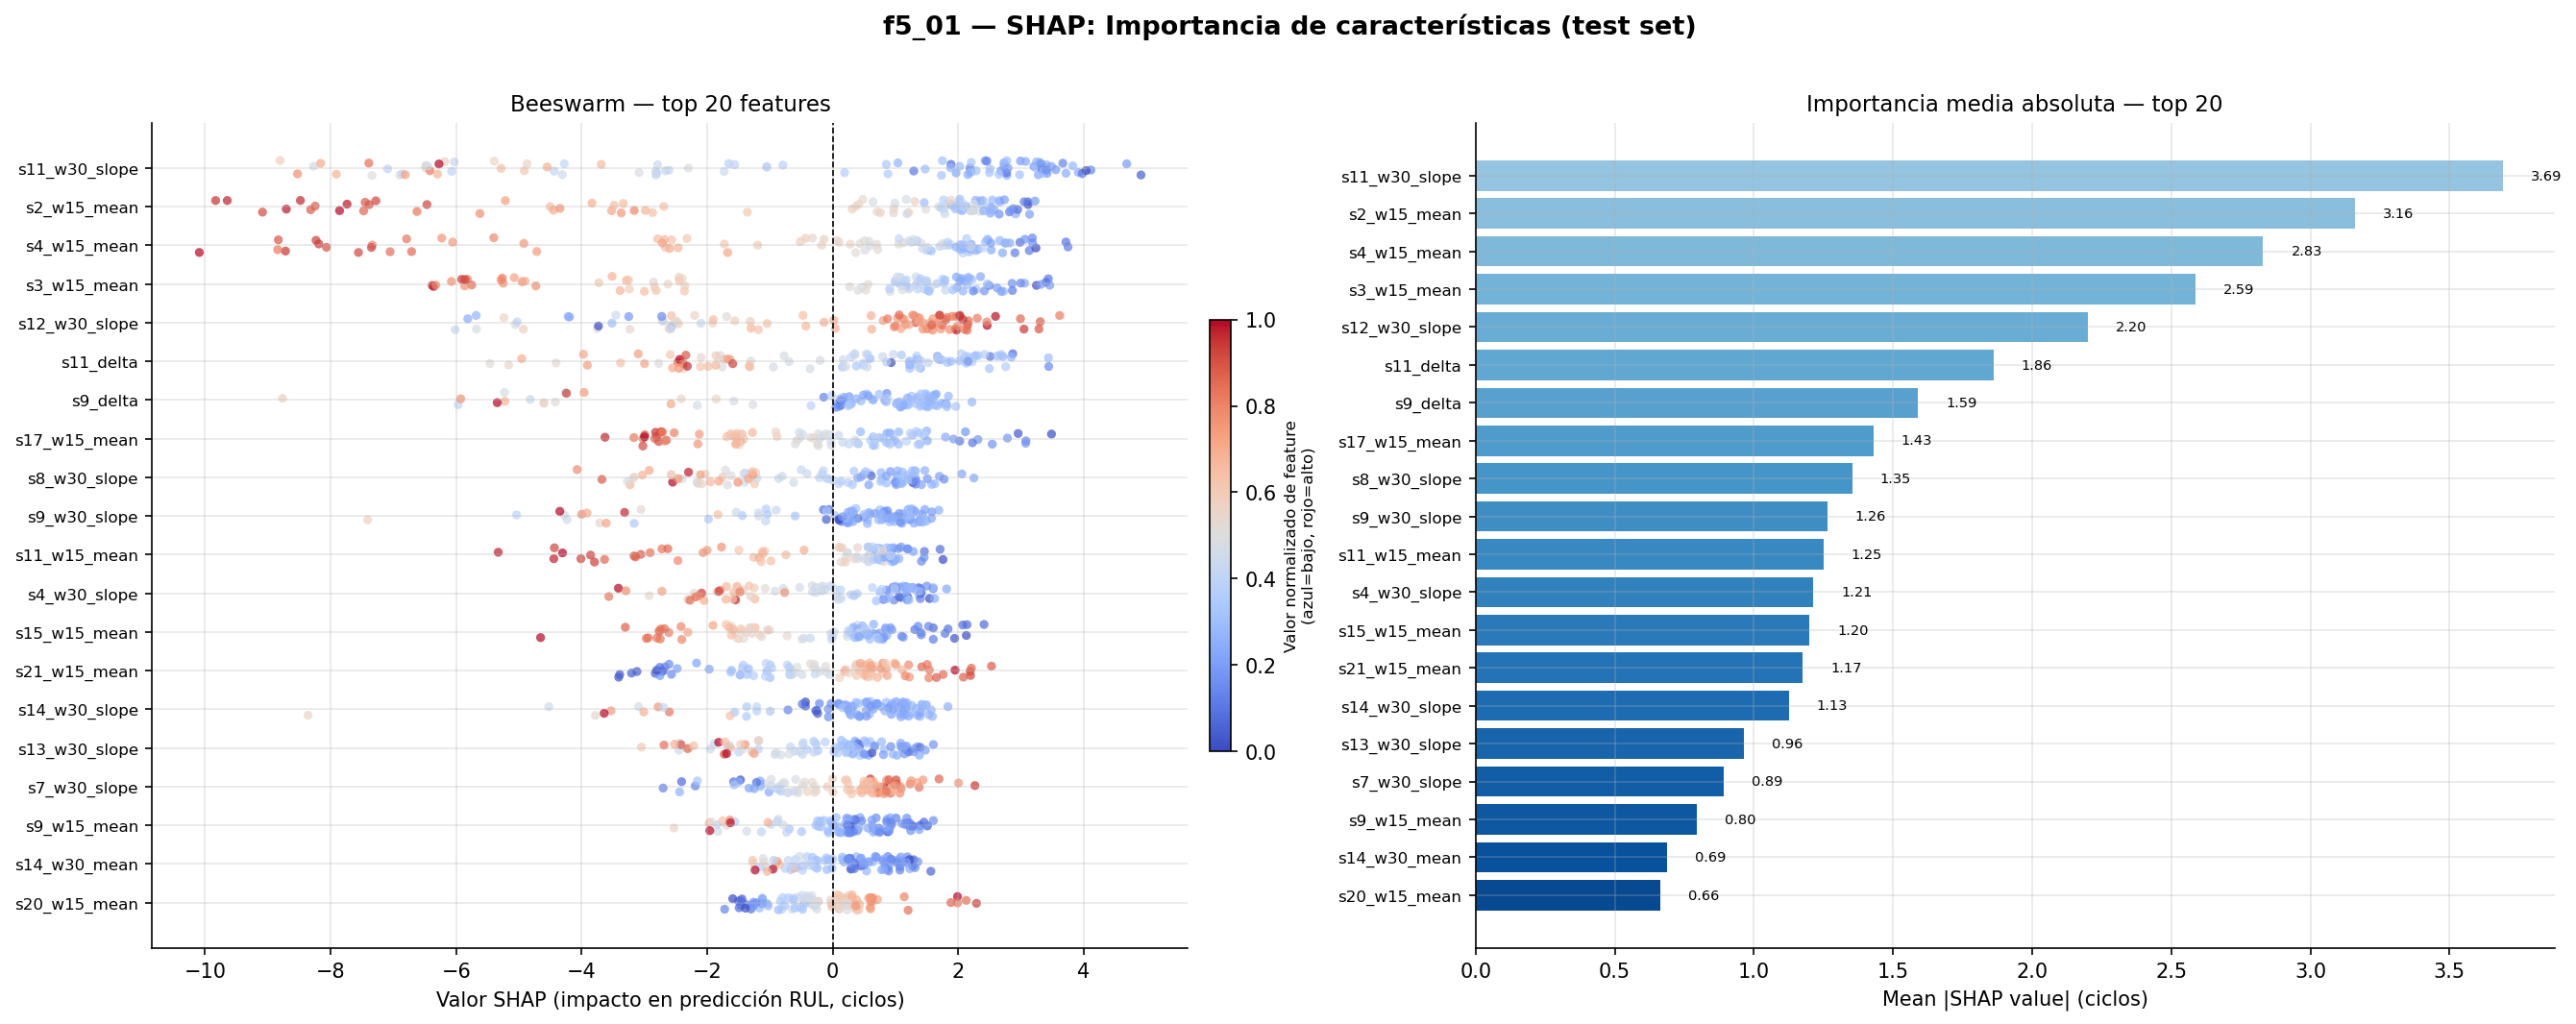

Top 5: ['s11_w30_slope', 's2_w15_mean', 's4_w15_mean', 's3_w15_mean', 's12_w30_slope']


In [9]:
import shap
rng = np.random.RandomState(42)
bg_idx = rng.choice(len(X_train_s), size=min(500, len(X_train_s)), replace=False)
explainer = shap.TreeExplainer(model, data=X_train_s[bg_idx], feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_s)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.Series(mean_abs_shap, index=feat_cols).sort_values(ascending=False)
top20 = feat_importance.head(20)

f5.plot_shap_summary(shap_values, X_test_s, feat_cols, top20,
                      save_path=f"{f0.OUTPUT_DIR}/f5_01_shap_summary.png")
display(Image(filename=f"{f0.OUTPUT_DIR}/f5_01_shap_summary.png"))
print("Top 5:", list(top20.index[:5]))


## 3. SHAP dependence — top 3 features

Muestra, para cada una de las 3 features más importantes, cómo varía su
valor SHAP en función de su propio valor (escalado) — color = RUL real.
Una tendencia clara (línea de regresión con pendiente marcada) indica
una relación monótona entre el sensor y la contribución a la
predicción; dispersión sin tendencia sugiere que el efecto de esa
feature depende de interacciones con otras (no capturadas en un
dependence plot 2D simple).


In [10]:
show_source(f5.plot_shap_dependence)

📍 plot_shap_dependence  —  scripts\fase5_evaluacion.py:255
------------------------------------------------------------------------------
def plot_shap_dependence(shap_values, X_test_s, feat_cols, top3, y_test, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("f5_02 — SHAP Dependence plots: top 3 features (test set)",
                 fontsize=13, fontweight="bold")
    for ax, feat_name in zip(axes, top3):
        fi = feat_cols.index(feat_name)
        sv = shap_values[:, fi]
        fv = X_test_s[:, fi]
        sc = ax.scatter(fv, sv, c=y_test, cmap="RdYlGn", s=40, vmin=0, vmax=RUL_CAP,
                        alpha=0.8, linewidths=0)
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        z = np.polyfit(fv, sv, 1)
        x_line = np.linspace(fv.min(), fv.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), color="black", linewidth=1.5,
                linestyle="--", label=f"tendencia (m={z[0]:.2f})")
        ax.set_xla

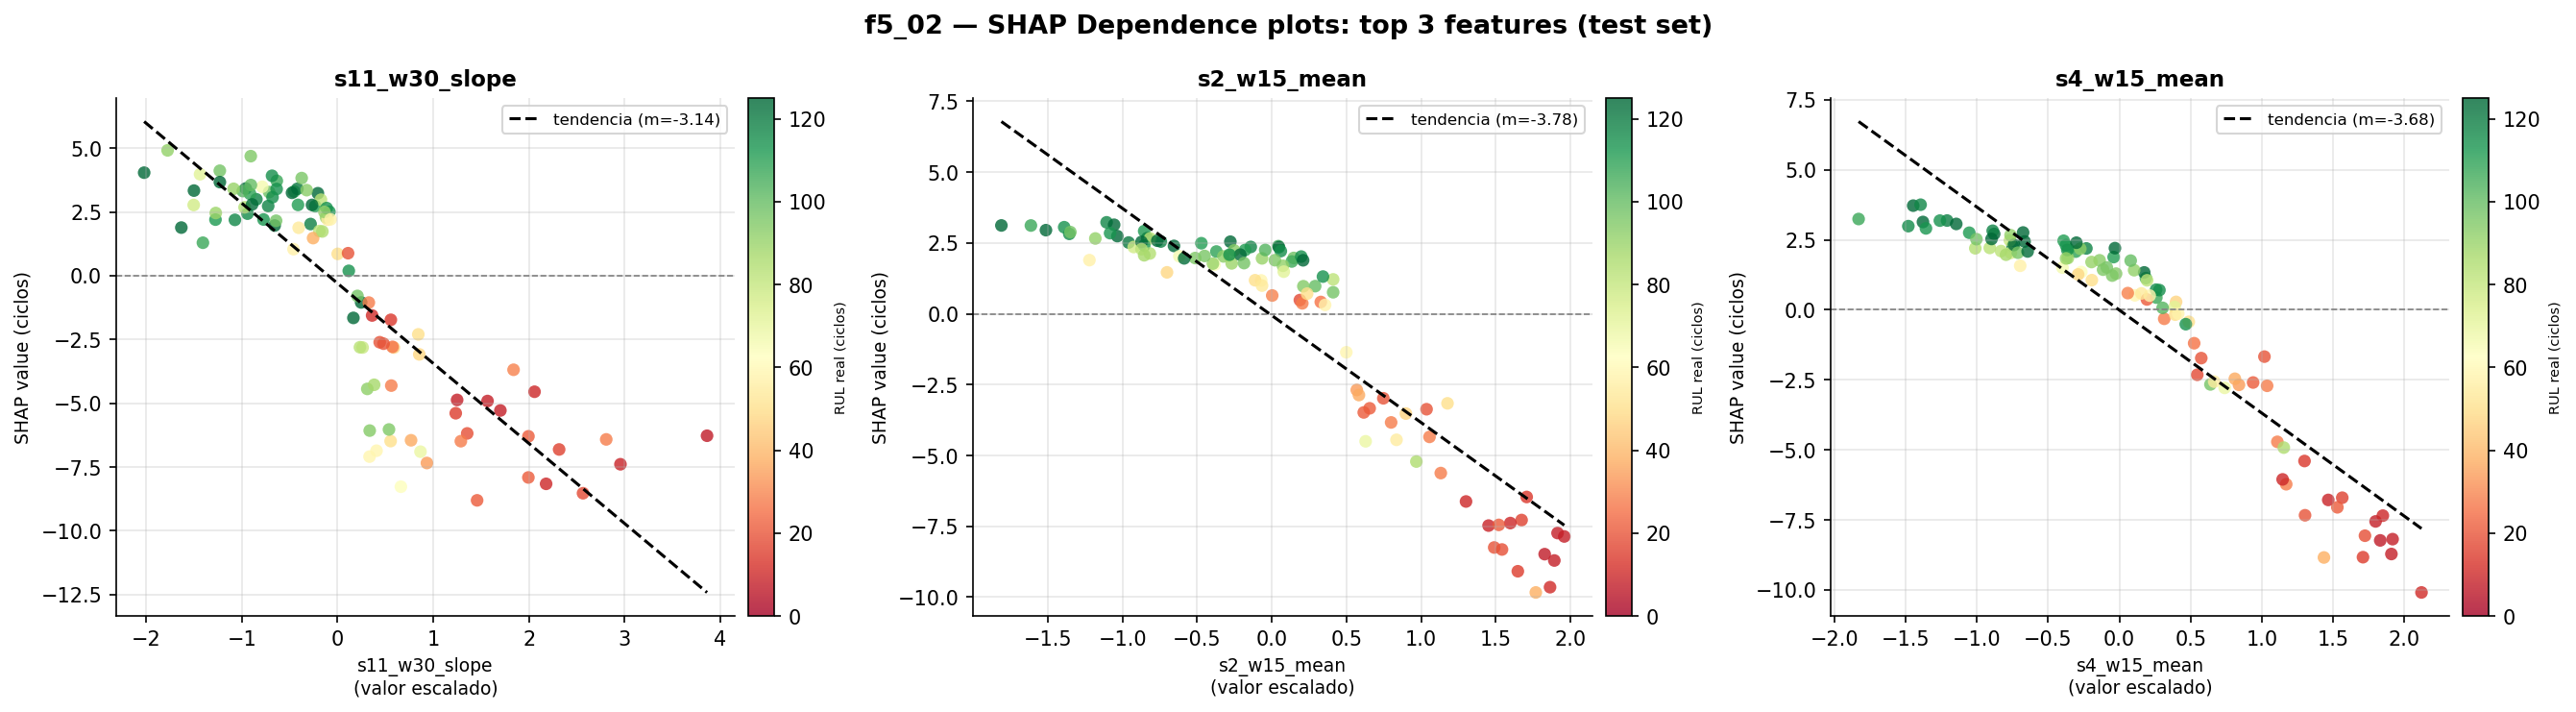

In [11]:
top3 = list(top20.index[:3])
f5.plot_shap_dependence(shap_values, X_test_s, feat_cols, top3, y_test,
                         save_path=f"{f0.OUTPUT_DIR}/f5_02_shap_dependence.png")
display(Image(filename=f"{f0.OUTPUT_DIR}/f5_02_shap_dependence.png"))


## 4. Curvas de degradación predicha vs. real

A diferencia de las secciones anteriores (que solo miran el último
ciclo de cada motor, el único punto con RUL verdadero "oficial"), aquí
se predice ciclo a ciclo sobre la trayectoria COMPLETA de test —
posible sin reconstruir nada porque `test_FD001_features_112.parquet`
(Fase 2) ya trae el RUL verdadero calculado en todos los ciclos
(`compute_rul_test_full`), no solo en el último.


In [12]:
show_source(f5.load_full_test_trajectories)

📍 load_full_test_trajectories  —  scripts\fase5_evaluacion.py:124
------------------------------------------------------------------------------
def load_full_test_trajectories(feat_cols: list):
    """
    Carga TODOS los ciclos de test (no solo el último) desde el mismo
    parquet que ya generó Fase 2 — que ya trae el RUL verdadero
    calculado en toda la trayectoria por cuenta atrás
    (`compute_rul_test_full`). Los primeros ciclos de cada motor tienen
    NaN en las features de pendiente (ventana incompleta); se
    rellenan con 0 solo para poder graficar la curva completa, igual
    que hacía la Fase 5 original.
    """
    test_full = pd.read_parquet(f"{OUTPUT_DIR}/test_FD001_features_112.parquet")
    test_full = test_full.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
    return test_full



In [13]:
show_source(f5.plot_degradation_curves)

📍 plot_degradation_curves  —  scripts\fase5_evaluacion.py:282
------------------------------------------------------------------------------
def plot_degradation_curves(model, scaler, test_full, feat_cols, n_motors=10, save_path=None):
    rul_df = pd.read_csv(f"{f0.DATA_DIR}/RUL_FD001.txt", header=None, names=["RUL_true"])
    rul_true_all = rul_df["RUL_true"].values.clip(0, RUL_CAP)
    rul_sorted = np.argsort(rul_true_all)
    selected_idx = [rul_sorted[i] for i in [5, 15, 30, 45, 55, 65, 75, 85, 92, 98]]
    selected_motors = [i + 1 for i in selected_idx]

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle("f5_03 — Degradación predicha vs. real: 10 motores representativos",
                 fontsize=13, fontweight="bold")
    gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

    for plot_i, eng_id in enumerate(selected_motors):
        ax = fig.add_subplot(gs[plot_i // 5, plot_i % 5])
        eng_data = test_full[test_full["engine_id"] == eng_id].sort_values(

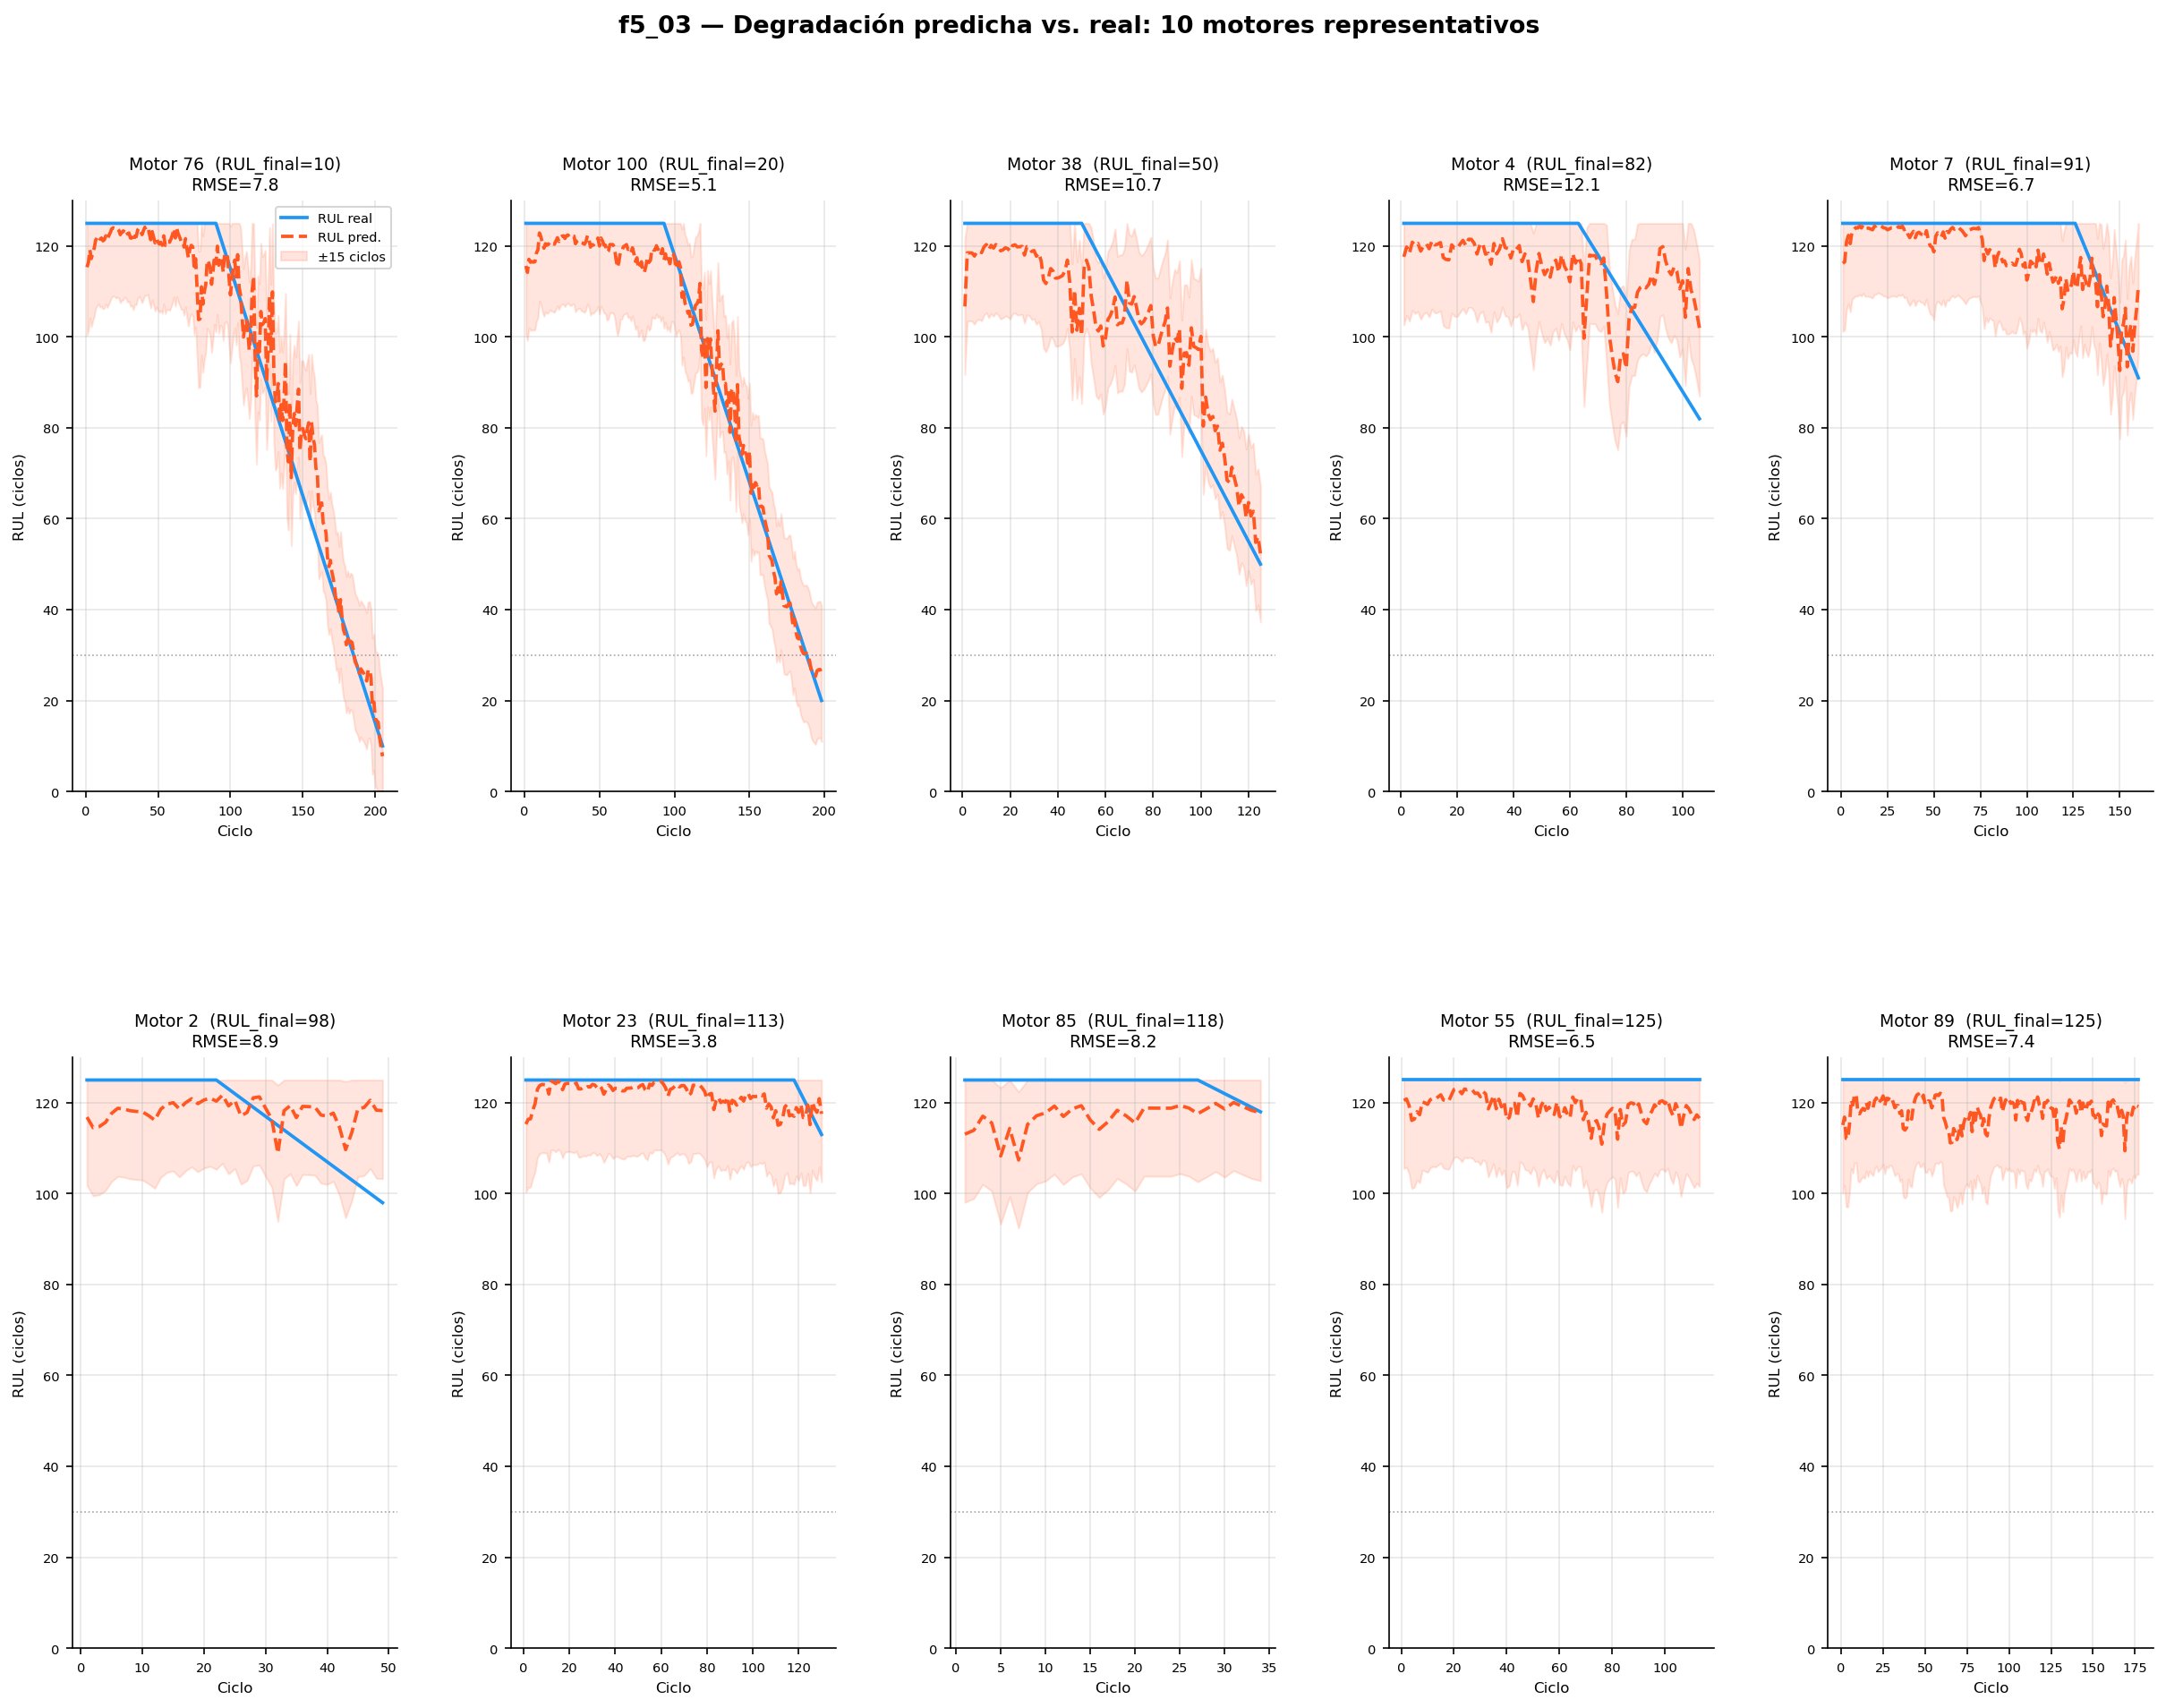

In [14]:
test_full = f5.load_full_test_trajectories(feat_cols)
f5.plot_degradation_curves(model, scaler, test_full, feat_cols,
                            save_path=f"{f0.OUTPUT_DIR}/f5_03_degradacion_predicha.png")
display(Image(filename=f"{f0.OUTPUT_DIR}/f5_03_degradacion_predicha.png"))


## 5. Error por tercil de RUL

**Base teórica — por qué mirar por tercil y no solo el RMSE global.**
Un RMSE agregado puede ocultar que el modelo se comporta muy distinto
según la fase de vida del motor. Se divide el test en terciles de RUL
real (tardía / media / temprana) y se mide RMSE, MAE, sesgo y
cobertura ±15 ciclos en cada uno — esta es la base empírica sobre la
que Fase 7 (Mejora 5) construye después el análisis formal de
heterocedasticidad (Breusch-Pagan): si el error varía sistemáticamente
con el RUL, cabe esperar que un test de heterocedasticidad lo confirme.


In [15]:
show_source(f5.plot_error_by_tercile)

📍 plot_error_by_tercile  —  scripts\fase5_evaluacion.py:320
------------------------------------------------------------------------------
def plot_error_by_tercile(y_test, y_pred, groups=None, save_path=None):
    abs_err = np.abs(y_pred - y_test)
    err_df = pd.DataFrame({"RUL_true": y_test, "RUL_pred": y_pred, "AE": abs_err,
                           "error_sign": y_pred - y_test})
    q33, q67 = np.percentile(y_test, [33, 67])
    err_df["tercil"] = pd.cut(err_df["RUL_true"], bins=[-1, q33, q67, RUL_CAP + 1],
                               labels=[f"Late\n(RUL<={q33:.0f})", f"Mid\n({q33:.0f}<RUL<={q67:.0f})",
                                      f"Early\n(RUL>{q67:.0f})"])
    stats_tercil = err_df.groupby("tercil", observed=True).agg(
        n=("AE", "count"), MAE=("AE", "mean"),
        RMSE=("AE", lambda x: np.sqrt(np.mean(x**2))),
        pct_within15=("AE", lambda x: (x <= 15).mean() * 100),
        bias=("error_sign", "mean"),
    ).round(2)

    fig, axes = plt.subplots(

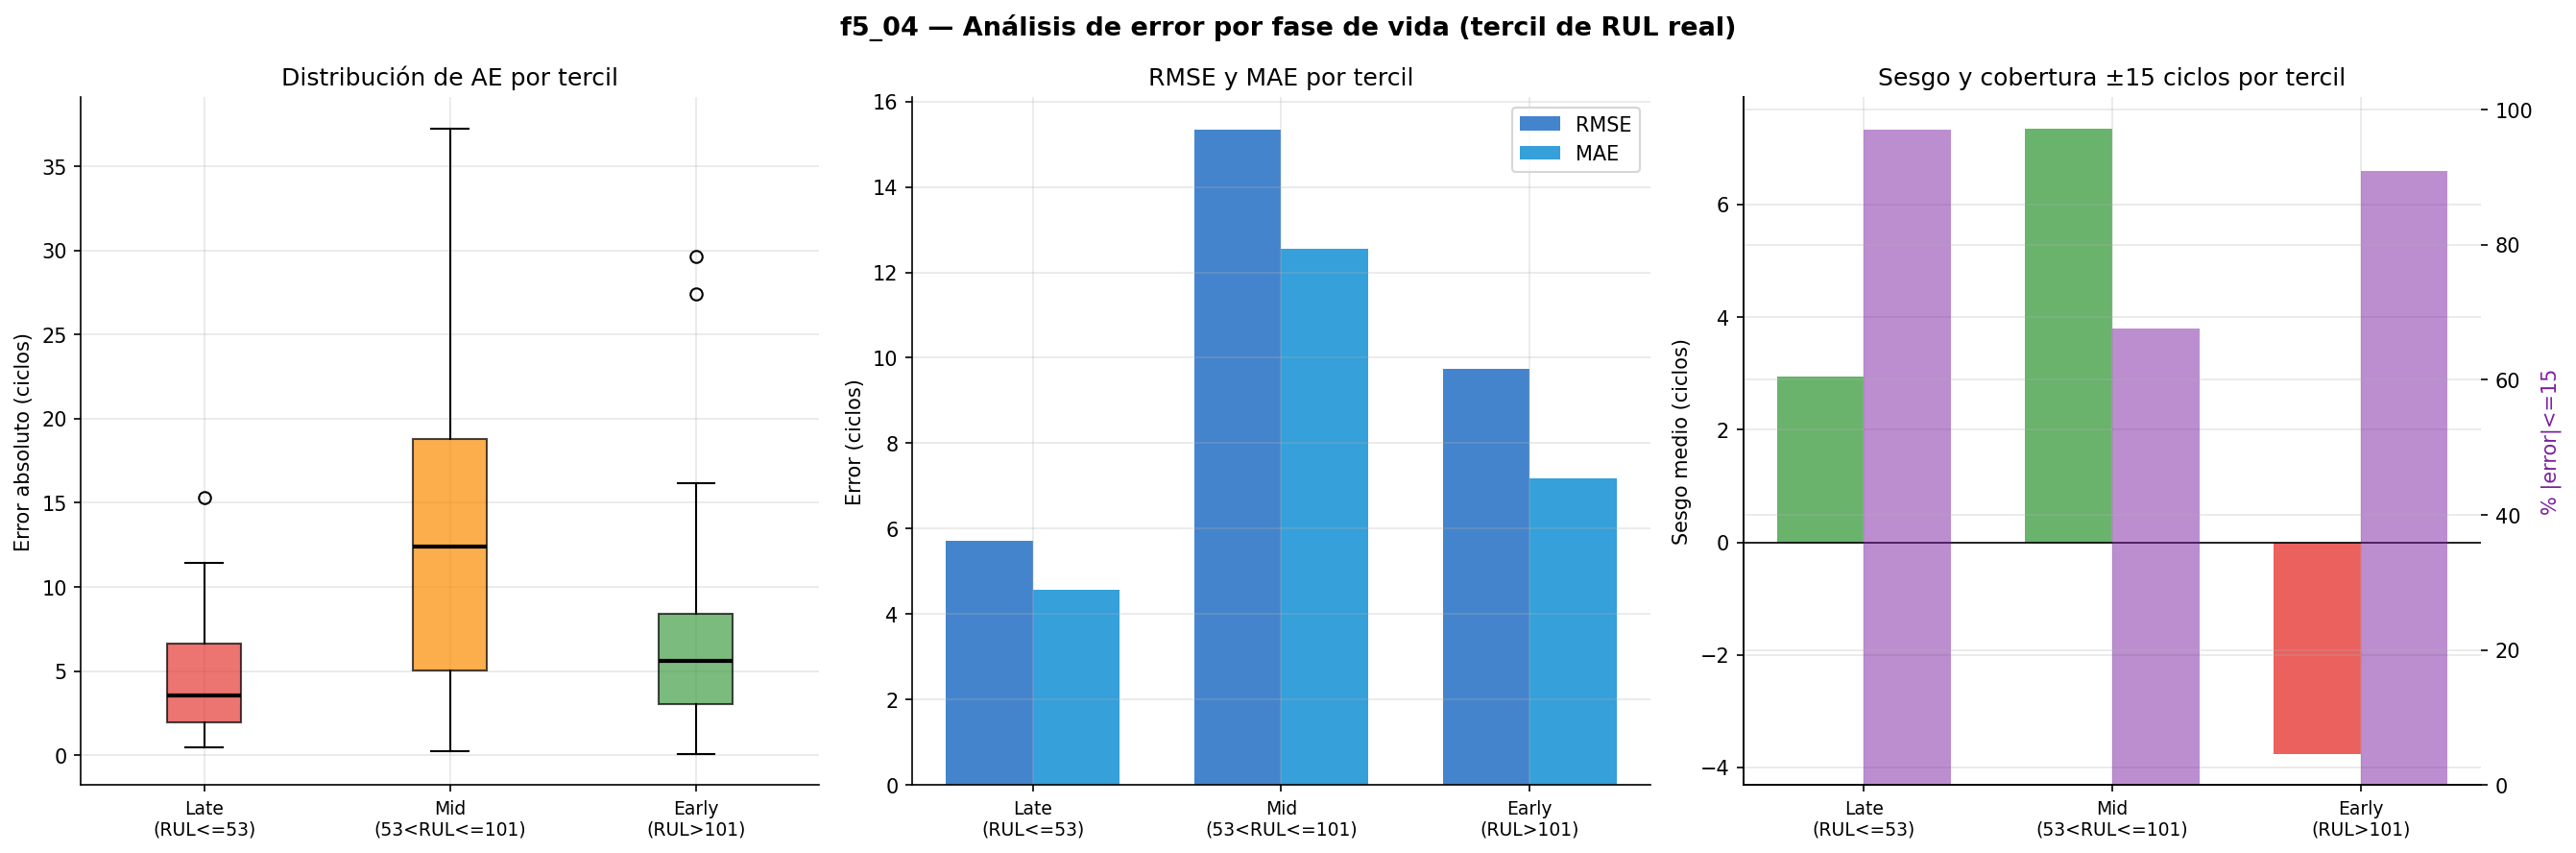

,n,MAE,RMSE,pct_within15,bias
tercil,,,,,
Late\n(RUL<=53),33,4.58,5.71,96.97,2.95
Mid\n(53<RUL<=101),34,12.54,15.33,67.65,7.35
Early\n(RUL>101),33,7.17,9.74,90.91,-3.76


In [16]:
stats_tercil = f5.plot_error_by_tercile(y_test, y_pred, save_path=f"{f0.OUTPUT_DIR}/f5_04_error_por_tercil.png")
display(Image(filename=f"{f0.OUTPUT_DIR}/f5_04_error_por_tercil.png"))
stats_tercil


## 6. Scatter predicho vs. real

In [17]:
show_source(f5.plot_scatter_density)

📍 plot_scatter_density  —  scripts\fase5_evaluacion.py:372
------------------------------------------------------------------------------
def plot_scatter_density(y_test, y_pred, save_path=None):
    xy = np.vstack([y_test, y_pred])
    kde = gaussian_kde(xy)(xy)
    order = kde.argsort()
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(y_test[order], y_pred[order], c=kde[order], cmap="viridis", s=60, alpha=0.85, linewidths=0)
    plt.colorbar(sc, ax=ax, label="Densidad KDE")
    lims = [0, RUL_CAP]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
    ax.fill_between(lims, [l - 15 for l in lims], [l + 15 for l in lims], alpha=0.12, color="red", label="±15 ciclos")
    z = np.polyfit(y_test, y_pred, 1)
    x_line = np.linspace(0, RUL_CAP, 100)
    ax.plot(x_line, np.polyval(z, x_line), "b-", linewidth=1.5, label=f"Regresión (m={z[0]:.2f})")
    rmse_t = np.sqrt(np.mean((y_pred - y_test) ** 2))
    mae_t = np.mean(np.abs(y_pred - y_test))
    r2_t 

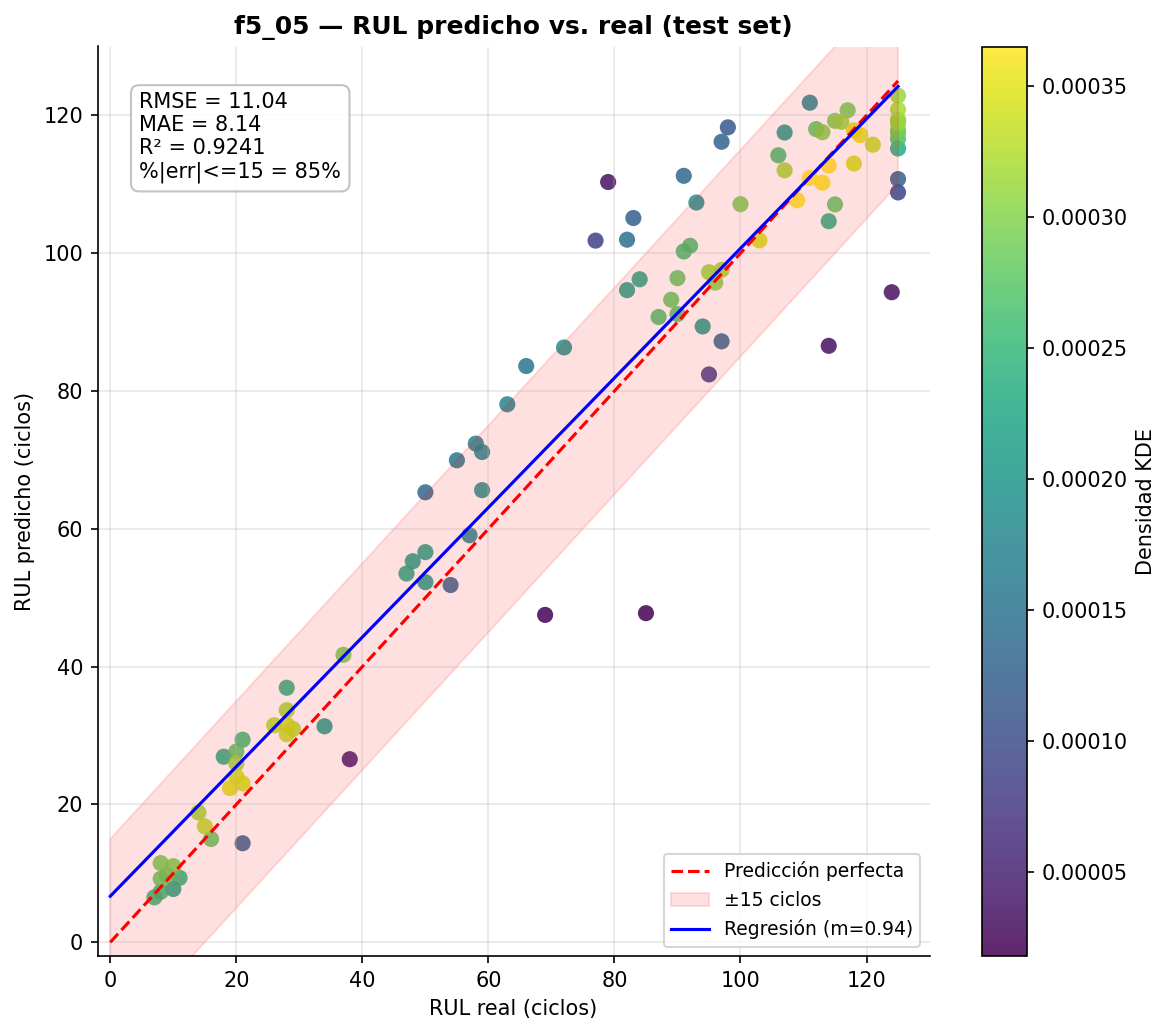

In [18]:
f5.plot_scatter_density(y_test, y_pred, save_path=f"{f0.OUTPUT_DIR}/f5_05_scatter_predicho_real.png")
display(Image(filename=f"{f0.OUTPUT_DIR}/f5_05_scatter_predicho_real.png"))


## 7. Resumen

| Elemento | Este run (RandomForest) | README histórico (XGBoost) |
|---|---|---|
| Modelo interpretado | RandomForest (auto-detectado, mejor test RMSE) | XGBoost (hardcodeado) |
| RMSE test | 11.04 | 12.80 |
| Top feature SHAP | `s11_w30_slope` | `s4_w15_mean` |
| RMSE tercil tardío | 5.71 | 6.20 |

El modelo interpretado cambió de XGBoost a RandomForest respecto a
versiones previas de este notebook — no por una decisión de diseño
nueva, sino porque `get_best_model_name()` corrige un bug real: el
notebook anterior asumía XGBoost sin comprobar si seguía siendo el
mejor modelo (dejó de serlo en esta revisión, ver
`fase4_modelado.ipynb` sección 4). El top feature SHAP también cambió
en consecuencia — es la propagación esperada de interpretar el modelo
correcto, no un error de esta fase.

**Fase 7 ya re-ejecutada y verificada** sobre los modelos de este run
(Diebold-Mariano/comparación pareada, censura, PHM score, SHAP
tree_path_dependent + ablación s14, Durbin-Watson/Breusch-Pagan,
ablación de ventanas) — no queda pendiente. Fase 7 mantiene XGBoost
como modelo de referencia para sus ablaciones (M1, M2, M4, M5), una
elección metodológica deliberada e independiente de cuál sea "el mejor
modelo" (ver `fase7_mejoras.py`).
